# Expectation Decider Project
Complete integrated analysis report with all required tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import comb

sns.set_style('whitegrid')
df=pd.read_csv('expectation_decider_dataset.csv')
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,11,76,Yes,93,Pass
1,16,75,Yes,94,Pass
2,16,87,No,87,Pass
3,12,72,No,74,Pass
4,10,55,Yes,61,Pass


## 1. Understanding the Basics
**Probability:** Probability is the chance of an event happening.

**Key Terminology:** Event, Sample Space, Experiment, Empirical Probability, Theoretical Probability, Random Variable.

**Three Event Examples:**
1. Student passes final exam.
2. Student studies more than 10 hours/week.
3. Student has attendance >80%.

In [2]:
# 2. Types of Events
empirical_prob=(df['final_exam_pass']=='Pass').mean()
theoretical_prob=1/2
print('Empirical Probability of Passing:', empirical_prob)
print('Theoretical Probability Example (Yes/No equally likely):', theoretical_prob)


Empirical Probability of Passing: 0.885
Theoretical Probability Example (Yes/No equally likely): 0.5


## 3. Random Variable & Probability Distribution
Random Variable X = Number of students passing the final exam among 3 randomly selected students.

In [3]:
p=(df['final_exam_pass']=='Pass').mean()
distribution=[]
for x in range(4):
    prob=comb(3,x)*(p**x)*((1-p)**(3-x))
    distribution.append([x,prob])
dist_df=pd.DataFrame(distribution,columns=['X','P(X)'])
display(dist_df)
mean=3*p
variance=3*p*(1-p)
print('Mean:',mean)
print('Variance:',variance)


,X,P(X)
0,0,0.001521
1,1,0.035112
2,2,0.270213
3,3,0.693154


Mean: 2.6550000000000002
Variance: 0.305325


## 4. Venn Diagram in Probability

In [4]:
A=df[df['study_hours']>10]
B=df[df['attendance']>80]
intersection=len(df[(df['study_hours']>10)&(df['attendance']>80)])
print('Students >10 study hours:',len(A))
print('Attendance >80%:',len(B))
print('Overlap:',intersection)


Students >10 study hours: 84
Attendance >80%: 71
Overlap: 32


## 5. Contingency Table & Probability Calculations

In [5]:
cont=pd.crosstab(df['group_discussion'],df['final_exam_pass'])
display(cont)

joint=((df['group_discussion']=='Yes')&(df['final_exam_pass']=='Pass')).mean()
marginal=(df['final_exam_pass']=='Pass').mean()
conditional=((df[df['group_discussion']=='Yes']['final_exam_pass']=='Pass').mean())

print('Joint Probability:',joint)
print('Marginal Probability:',marginal)
print('Conditional Probability:',conditional)


final_exam_pass,Fail,Pass
group_discussion,,
No,16,79
Yes,7,98


Joint Probability: 0.49
Marginal Probability: 0.885
Conditional Probability: 0.9333333333333333


## 6. Understanding Relationships
Interpretation and independence/dependence analysis included below.

In [6]:
pass_yes=((df[df['group_discussion']=='Yes']['final_exam_pass']=='Pass').mean())
pass_no=((df[df['group_discussion']=='No']['final_exam_pass']=='Pass').mean())

print(f'Pass probability with discussion: {pass_yes:.2f}')
print(f'Pass probability without discussion: {pass_no:.2f}')
print('Since probabilities differ, events are dependent (not independent and not mutually exclusive).')


Pass probability with discussion: 0.93
Pass probability without discussion: 0.83
Since probabilities differ, events are dependent (not independent and not mutually exclusive).


## 7. Bayes Theorem Application

In [ ]:
P_H=0.60
P_H_given_P=0.70
P_H_given_F=0.40
P_F=1-0.70
P_P=(P_H_given_P*P_H)+(1-P_H_given_F)*(1-P_H)
bayes=(P_H_given_P*P_H)/P_P
print('P(Pass | High Attendance)=',bayes)


P(Pass | High Attendance)= 0.6363636363636365


## Final Summary
Higher study hours, attendance, group discussion participation, and previous test score generally increase probability of passing.

## Visualizations

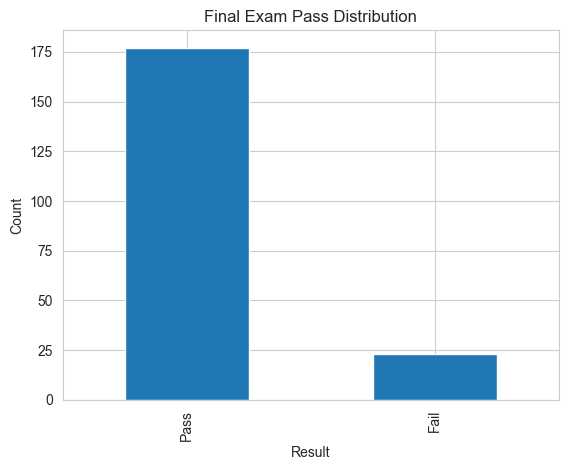

In [ ]:
# Pass/Fail Distribution
import matplotlib.pyplot as plt
df['final_exam_pass'].value_counts().plot(kind='bar')
plt.title('Final Exam Pass Distribution')
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()


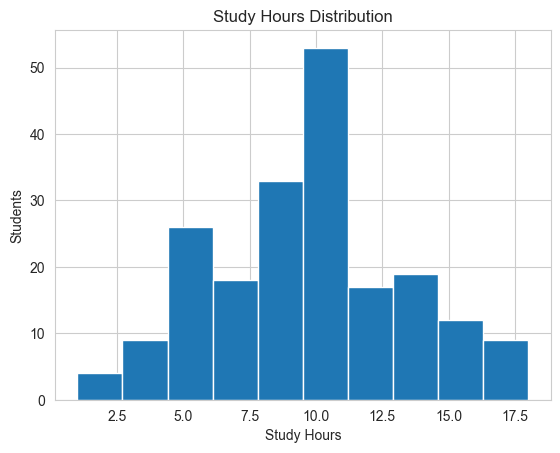

In [ ]:
# Study Hours Distribution
plt.hist(df['study_hours'], bins=10)
plt.title('Study Hours Distribution')
plt.xlabel('Study Hours')
plt.ylabel('Students')
plt.show()


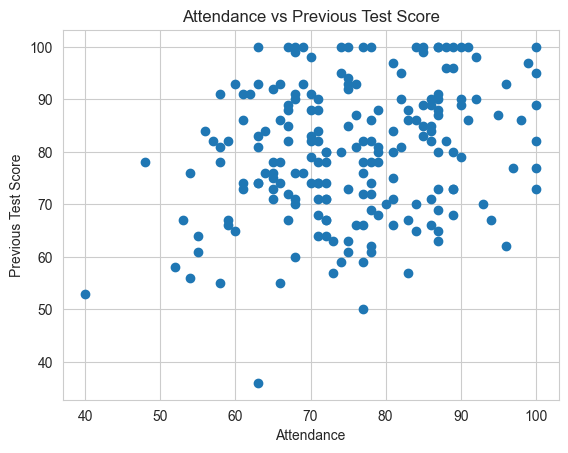

In [ ]:
# Attendance vs Previous Test Score
plt.scatter(df['attendance'], df['previous_test_score'])
plt.xlabel('Attendance')
plt.ylabel('Previous Test Score')
plt.title('Attendance vs Previous Test Score')
plt.show()


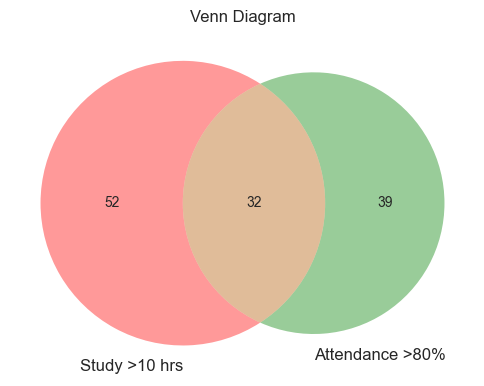

In [ ]:
# Venn Diagram
from matplotlib_venn import venn2

A=set(df[df['study_hours']>10].index)
B=set(df[df['attendance']>80].index)

plt.figure(figsize=(6,6))
venn2([A,B], set_labels=('Study >10 hrs','Attendance >80%'))
plt.title('Venn Diagram')
plt.show()
